# Horizon-20 benchmark data

Load the complete physical-event horizon benchmark into one tidy DataFrame. This notebook intentionally performs no analysis or visualization.

The loader reads only the top-level JSONL files in `derived/results/horizon_curves`, excluding the nested duplicate download directory.

In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path

import pandas as pd

REPO_ROOT = Path.cwd() if (Path.cwd() / 'derived').is_dir() else Path.cwd().parent
RESULTS_DIR = REPO_ROOT / 'derived' / 'results' / 'horizon_curves'
FILENAME_PATTERN = re.compile(
    r'^horizons_(?P<dynamic>diffusion|wave|coupled_oscillator)_'
    r'(?P<topology>ring|grid|torus|doorway|swisscheese)_'
    r'models(?P<models>\d+)_epochs(?P<epochs>\d+)_nodes(?P<num_nodes>\d+)_'
    r'episodes(?P<num_episodes>\d+)_bins(?P<num_bins>\d+)_events(?P<events_per_bin>\d+)_'
    r'dropint(?P<raindrop_interval>\d+)_tau(?P<event_threshold>[0-9p]+)_'
    r'trainroll(?P<rollout_train_steps>\d+)_rollhorizon(?P<rollout_horizon>\d+)_'
    r'dt(?P<synthetic_dt>[0-9p]+)_gamma(?P<synthetic_gamma>[0-9p]+)_'
    r'omega(?P<synthetic_omega>[0-9p]+)_forcescale(?P<synthetic_force_scale>[0-9p]+)_'
    r'seed(?P<seed>\d+)\.jsonl$'
)


In [2]:
def decode_numeric_tag(value: str) -> float:
    return float(value.replace('p', '.'))


def load_horizon_results(results_dir: Path) -> pd.DataFrame:
    # glob(), rather than rglob(), deliberately excludes
    # horizon_curves/horizon_curves/, which is a byte-identical duplicate.
    paths = sorted(results_dir.glob('horizons_*.jsonl'))
    if not paths:
        raise FileNotFoundError(f'No horizon JSONLs found in {results_dir}')

    records: list[dict] = []
    for path in paths:
        match = FILENAME_PATTERN.fullmatch(path.name)
        if match is None:
            raise ValueError(f'Unexpected horizon-results filename: {path.name}')

        metadata = match.groupdict()
        metadata = {
            key: (decode_numeric_tag(value) if key.startswith(('event_threshold', 'synthetic_')) else value)
            for key, value in metadata.items()
        }
        metadata.update({
            key: int(value)
            for key, value in match.groupdict().items()
            if key not in {'dynamic', 'topology', 'event_threshold', 'synthetic_dt', 'synthetic_gamma', 'synthetic_omega', 'synthetic_force_scale'}
        })

        with path.open(encoding='utf-8') as handle:
            for line_number, line in enumerate(handle, start=1):
                row = json.loads(line)
                row['source_file'] = path.name
                row['source_line'] = line_number
                row.update(metadata)
                records.append(row)

    # Flatten scalar metric dictionaries one level while retaining detailed
    # rollout curves (for example `rollout_test.rollout_by_step`) as
    # object-valued columns. This keeps every raw result available without
    # expanding variable-length curves into thousands of sparse columns.
    return pd.json_normalize(records, sep='.', max_level=1)


horizon_df = load_horizon_results(RESULTS_DIR)
horizon_df


,run,seed,epoch,source_file,source_line,dynamic,topology,models,epochs,num_nodes,...,train_step.qdot_norm_mean,train_step.qddot_norm_mean,train_step.H_tot_mean,train_step.q_norm_mean,train_step.p_norm_mean,train_step.dqdt_norm_mean,train_step.dpdt_norm_mean,train_step.dqdt_next_norm_mean,val.early_active_force_mse,val.persistent_early_active_force_mse
0,fnn,0,1,horizons_coupled_oscillator_doorway_models7_ep...,1,coupled_oscillator,doorway,7,20,64,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,fnn,0,2,horizons_coupled_oscillator_doorway_models7_ep...,2,coupled_oscillator,doorway,7,20,64,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,fnn,0,3,horizons_coupled_oscillator_doorway_models7_ep...,3,coupled_oscillator,doorway,7,20,64,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,fnn,0,4,horizons_coupled_oscillator_doorway_models7_ep...,4,coupled_oscillator,doorway,7,20,64,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,fnn,0,5,horizons_coupled_oscillator_doorway_models7_ep...,5,coupled_oscillator,doorway,7,20,64,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10495,settransformer/hnn,4,16,horizons_wave_torus_models7_epochs20_nodes64_e...,136,wave,torus,7,20,64,...,NaN,NaN,-95051.788592,235.761939,233.339101,8.036111,8.022092,8.102905,NaN,NaN
10496,settransformer/hnn,4,17,horizons_wave_torus_models7_epochs20_nodes64_e...,137,wave,torus,7,20,64,...,NaN,NaN,7007.776123,161.777575,138.563562,5.482036,5.404493,5.996172,NaN,NaN
10497,settransformer/hnn,4,18,horizons_wave_torus_models7_epochs20_nodes64_e...,138,wave,torus,7,20,64,...,NaN,NaN,-66048.450248,268.278568,247.683217,7.885092,7.430837,7.998983,NaN,NaN
10498,settransformer/hnn,4,19,horizons_wave_torus_models7_epochs20_nodes64_e...,139,wave,torus,7,20,64,...,NaN,NaN,5297.730488,211.045787,183.669896,6.315758,5.774492,6.561365,NaN,NaN


In [5]:
# Basic experimental structure
print("rows:", len(horizon_df))
print("columns:", len(horizon_df.columns))

display(
    horizon_df[
        [
            "dynamic",
            "topology",
            "run",
            "seed",
            "epoch",
        ]
    ]
    .drop_duplicates()
    .groupby(["dynamic", "topology", "run"])
    .agg(
        seeds=("seed", "nunique"),
        epochs=("epoch", "nunique"),
        rows=("epoch", "size"),
    )
    .reset_index()
    .sort_values(["dynamic", "topology", "run"])
)

print("\nDynamics:")
print(horizon_df["dynamic"].value_counts())

print("\nTopologies:")
print(horizon_df["topology"].value_counts())

print("\nModels:")
print(sorted(horizon_df["run"].dropna().unique()))

rows: 10500
columns: 2082


,dynamic,topology,run,seeds,epochs,rows
0,coupled_oscillator,doorway,deepsets/tgn_gru,5,20,100
1,coupled_oscillator,doorway,fnn,5,20,100
2,coupled_oscillator,doorway,hopfield/hopfield_update,5,20,100
3,coupled_oscillator,doorway,settransformer/hnn,5,20,100
4,coupled_oscillator,doorway,settransformer/lnn,5,20,100
...,...,...,...,...,...,...
100,wave,torus,hopfield/hopfield_update,5,20,100
101,wave,torus,settransformer/hnn,5,20,100
102,wave,torus,settransformer/lnn,5,20,100
103,wave,torus,settransformer/tgn_gru,5,20,100



Dynamics:
dynamic
coupled_oscillator    3500
diffusion             3500
wave                  3500
Name: count, dtype: int64

Topologies:
topology
doorway        2100
grid           2100
ring           2100
swisscheese    2100
torus          2100
Name: count, dtype: int64

Models:
['deepsets/tgn_gru', 'fnn', 'hopfield/hopfield_update', 'settransformer/hnn', 'settransformer/lnn', 'settransformer/tgn_gru', 'sum/tgn_gru']


In [9]:
rollout_rows = horizon_df[
    horizon_df["rollout_test.rollout_by_step"].notna()
].copy()

display(
    rollout_rows.groupby("epoch")
    .size()
    .rename("n")
    .reset_index()
)

print("rollout rows:", len(rollout_rows))
print(
    "unique conditions:",
    rollout_rows[
        ["dynamic", "topology", "run", "seed"]
    ].drop_duplicates().shape[0]
)

,epoch,n
0,20,525


rollout rows: 525
unique conditions: 525


In [46]:
def explode_rollout_by_step(
    df: pd.DataFrame,
    curve_col: str = "rollout_test.rollout_by_step",
) -> pd.DataFrame:
    id_cols = [
        "dynamic",
        "topology",
        "run",
        "seed",
        "epoch",
        "num_nodes",
        "rollout_horizon",
        "synthetic_dt",
        "synthetic_gamma",
        "synthetic_omega",
        "synthetic_force_scale",
    ]

    records = []

    for _, row in df[df[curve_col].notna()].iterrows():
        curve = row[curve_col]

        for horizon, metrics in curve.items():
            record = {
                col: row[col]
                for col in id_cols
                if col in row.index
            }

            record["horizon"] = int(horizon)
            record.update(metrics)
            records.append(record)

    return pd.DataFrame(records)


# ============================================================
# Analysis scope
# ============================================================

DYNAMICS = ["diffusion", "wave"]


# ============================================================
# Learned-model rollout curves
# ============================================================

horizon_models = explode_rollout_by_step(
    horizon_df,
    curve_col="rollout_test.rollout_by_step",
)

horizon_models = (
    horizon_models[
        horizon_models["dynamic"].isin(DYNAMICS)
    ]
    .sort_values(
        ["dynamic", "topology", "run", "seed", "horizon"]
    )
    .reset_index(drop=True)
)


# ============================================================
# Matched no-update ablation
#
# IMPORTANT:
# This is NOT a shared persistence baseline.
#
# For each trained model, its own latent state is frozen at
# rollout start and future predictions are produced using that
# model's own learned decoder.
# ============================================================

matched_no_update_test = explode_rollout_by_step(
    horizon_df,
    curve_col="rollout_test.rollout_persistent_by_step",
)

matched_no_update_test = (
    matched_no_update_test[
        matched_no_update_test["dynamic"].isin(DYNAMICS)
    ]
    .rename(columns={"run": "source_run"})
    .sort_values(
        ["dynamic", "topology", "source_run", "seed", "horizon"]
    )
    .reset_index(drop=True)
)


# ============================================================
# Shared data-only persistence baseline
#
# This should eventually contain one prediction curve per:
#
# dynamic × topology × seed × horizon
#
# based on freezing the LAST OBSERVED FORCE TARGET at rollout
# start, independent of any learned model.
#
# When that baseline is added to the evaluation output, extract
# it here and set:
#
#     persistence_test["run"] = "persistent"
#
# Then append it to horizon_models below.
# ============================================================

persistence_test = None


# ============================================================
# Main cross-model horizon dataframe
# ============================================================

if persistence_test is None:
    horizon_test = horizon_models.copy()
else:
    horizon_test = pd.concat(
        [horizon_models, persistence_test],
        ignore_index=True,
    )

horizon_test = (
    horizon_test
    .sort_values(
        ["dynamic", "topology", "run", "seed", "horizon"]
    )
    .reset_index(drop=True)
)


# ============================================================
# Audit
# ============================================================

display(
    horizon_test
    .groupby(["dynamic", "run"])
    .agg(
        topologies=("topology", "nunique"),
        seeds=("seed", "nunique"),
        horizons=("horizon", "nunique"),
        rows=("horizon", "size"),
    )
    .reset_index()
    .sort_values(["dynamic", "run"])
)

print(f"Main horizon rows: {len(horizon_test):,}")
print(f"Matched no-update rows: {len(matched_no_update_test):,}")
print(f"Models: {sorted(horizon_test['run'].unique())}")

,dynamic,run,topologies,seeds,horizons,rows
0,diffusion,deepsets/tgn_gru,5,5,20,500
1,diffusion,fnn,5,5,20,500
2,diffusion,hopfield/hopfield_update,5,5,20,500
3,diffusion,settransformer/hnn,5,5,20,500
4,diffusion,settransformer/lnn,5,5,20,500
5,diffusion,settransformer/tgn_gru,5,5,20,500
6,diffusion,sum/tgn_gru,5,5,20,500
7,wave,deepsets/tgn_gru,5,5,20,500
8,wave,fnn,5,5,20,500
9,wave,hopfield/hopfield_update,5,5,20,500


Main horizon rows: 7,000
Matched no-update rows: 7,000
Models: ['deepsets/tgn_gru', 'fnn', 'hopfield/hopfield_update', 'settransformer/hnn', 'settransformer/lnn', 'settransformer/tgn_gru', 'sum/tgn_gru']


In [83]:
import matplotlib.pyplot as plt
import numpy as np


# ============================================================
# Paper typography
# ============================================================

plt.rcParams.update({
    "font.family": "sans-serif",
    #"font.sans-serif": [PAPER_FONT],
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 6.4,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.dpi": 600,
})


# ============================================================
# Display ordering / labels
# ============================================================

DYNAMIC_ORDER = [
    "diffusion",
    "wave",
]

DYNAMIC_LABELS = {
    "diffusion": "Diffusion",
    "wave": "Wave",
}

TOPOLOGY_ORDER = [
    "ring",
    "grid",
    "torus",
    "doorway",
    "swisscheese",
]

TOPOLOGY_LABELS = {
    "ring": "Ring",
    "grid": "Grid",
    "torus": "Torus",
    "doorway": "Doorway",
    "swisscheese": "Swiss cheese",
}

MODEL_ORDER = [
    "fnn",
    "sum/tgn_gru",
    "deepsets/tgn_gru",
    "settransformer/tgn_gru",
    "hopfield/hopfield_update",
    "settransformer/lnn",
    "settransformer/hnn",
]

MODEL_LABELS = {
    "fnn": "FNN",
    "sum/tgn_gru": "GRU",
    "deepsets/tgn_gru": "DeepSets",
    "settransformer/tgn_gru": "SetTransformer",
    "hopfield/hopfield_update": "Hopfield",
    "settransformer/lnn": "LNN",
    "settransformer/hnn": "HNN",
}


# ============================================================
# Model styles
# ============================================================

BASELINE_COLORS = plt.get_cmap("tab10").colors

MODEL_MARKERS = {
    "fnn": "o",
    "sum/tgn_gru": "s",
    "deepsets/tgn_gru": "^",
    "settransformer/tgn_gru": "D",
    "hopfield/hopfield_update": "P",
    "settransformer/lnn": "X",
    "settransformer/hnn": "v",
}

# Keep FNN blue and visually dominant.
MODEL_COLORS = {
    "fnn": "#0072B2",
    "sum/tgn_gru": BASELINE_COLORS[1],
    "deepsets/tgn_gru": BASELINE_COLORS[2],
    "settransformer/tgn_gru": BASELINE_COLORS[3],
    "hopfield/hopfield_update": BASELINE_COLORS[4],
    "settransformer/lnn": BASELINE_COLORS[5],
    "settransformer/hnn": BASELINE_COLORS[6],
}

MODEL_LINEWIDTHS = {
    run: 1.7 if run == "fnn" else 1.2
    for run in MODEL_ORDER
}

MODEL_ZORDERS = {
    run: 4 if run == "fnn" else 2
    for run in MODEL_ORDER
}

MARKER_STEPS = (5, 10, 15, 20)


# ============================================================
# Curve aggregation
# ============================================================

def aggregate_seed_curves(seed_curves):
    """
    seed_curves:
        dict[seed] -> dict[horizon] -> value

    Returns:
        steps, mean, lower, upper

    Bands are mean +/- 1 SEM, matching the earlier figure style.
    """
    steps = sorted({
        step
        for curve in seed_curves.values()
        for step in curve
    })

    mean = []
    lower = []
    upper = []

    for step in steps:
        values = np.asarray([
            curve[step]
            for curve in seed_curves.values()
            if step in curve
        ], dtype=float)

        center = values.mean()

        if len(values) < 2:
            sem = 0.0
        else:
            sem = values.std(ddof=1) / np.sqrt(len(values))

        mean.append(center)
        lower.append(max(center - sem, 1e-12))
        upper.append(max(center + sem, 1e-12))

    return steps, mean, lower, upper


# ============================================================
# Axis styling helper
# ============================================================

def style_rollout_axis(
    ax,
    *,
    title=None,
    ylabel=None,
    xlabel=None,
    max_horizon=20,
    log_y=True,
):
    if title is not None:
        ax.set_title(title, loc="left")

    if ylabel is not None:
        ax.set_ylabel(ylabel)

    if xlabel is not None:
        ax.set_xlabel(xlabel)

    ax.set_xlim(1, max_horizon)
    ax.set_xticks([1, 5, 10, 15, 20])

    if log_y:
        ax.set_yscale("log")

    ax.grid(
        axis="y",
        color="0.88",
        linewidth=0.5,
    )
    ax.grid(
        axis="x",
        visible=False,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(
        axis="both",
        length=2.5,
        width=0.6,
    )


# ============================================================
# Single model curve helper
# ============================================================

def plot_model_curve(
    ax,
    steps,
    mean,
    lower,
    upper,
    run,
):
    color = MODEL_COLORS[run]

    marker_indices = [
        steps.index(step)
        for step in MARKER_STEPS
        if step in steps
    ]

    ax.fill_between(
        steps,
        lower,
        upper,
        color=color,
        alpha=0.16,
        linewidth=0,
        zorder=1,
    )

    line, = ax.plot(
        steps,
        mean,
        label=MODEL_LABELS[run],
        color=color,
        linewidth=MODEL_LINEWIDTHS[run],
        marker=MODEL_MARKERS[run],
        markersize=5.5,
        markerfacecolor="white",
        markeredgecolor=color,
        markeredgewidth=1.15,
        markevery=marker_indices,
        zorder=MODEL_ZORDERS[run],
    )

    return line

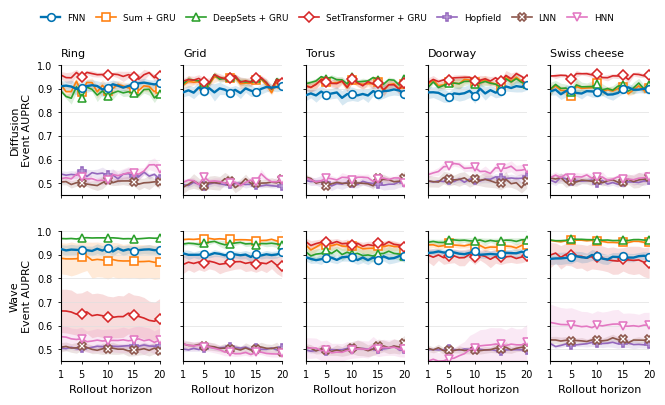

In [60]:

METRIC = "event_auprc" #force_nrmse
Y_LABEL = "Event AUPRC" #FORCE NRMSE
LOG_Y = False

fig, axes = plt.subplots(
    len(DYNAMIC_ORDER),
    len(TOPOLOGY_ORDER),
    figsize=(6.5, 4.0),
    sharex=True,
    sharey="row",
)

legend_handles = {}

for row_idx, dynamic in enumerate(DYNAMIC_ORDER):
    for col_idx, topology in enumerate(TOPOLOGY_ORDER):

        ax = axes[row_idx, col_idx]

        panel = horizon_test[
            (horizon_test["dynamic"] == dynamic)
            & (horizon_test["topology"] == topology)
        ]

        draw_order = [
            run for run in MODEL_ORDER
            if run != "fnn"
        ] + ["fnn"]

        for run in draw_order:

            model_data = panel[
                panel["run"] == run
            ]

            if model_data.empty:
                continue

            seed_curves = {
                seed: dict(
                    zip(
                        seed_df["horizon"],
                        seed_df[METRIC],
                    )
                )
                for seed, seed_df in model_data.groupby("seed")
            }

            steps, mean, lower, upper = aggregate_seed_curves(
                seed_curves
            )

            line = plot_model_curve(
                ax,
                steps,
                mean,
                lower,
                upper,
                run,
            )

            legend_handles.setdefault(run, line)

        style_rollout_axis(
            ax,
            title=(
                TOPOLOGY_LABELS[topology]
                if row_idx == 0
                else None
            ),
            ylabel=(
                f"{DYNAMIC_LABELS[dynamic]}\n{Y_LABEL}"
                if col_idx == 0
                else None
            ),
            xlabel=(
                "Rollout horizon"
                if row_idx == len(DYNAMIC_ORDER) - 1
                else None
            ),
            max_horizon=20,
            log_y=LOG_Y,
        )

        # AUPRC/AUROC live naturally on [0, 1]
        ax.set_ylim(0.45, 1.0)


present_runs = [
    run for run in MODEL_ORDER
    if run in legend_handles
]

fig.legend(
    [legend_handles[run] for run in present_runs],
    [MODEL_LABELS[run] for run in present_runs],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=len(present_runs),
    frameon=False,
    columnspacing=1.2,
    handlelength=2.2,
)

fig.subplots_adjust(
    left=0.09,
    right=0.995,
    bottom=0.12,
    top=0.86,
    wspace=0.24,
    hspace=0.28,
)

plt.show()

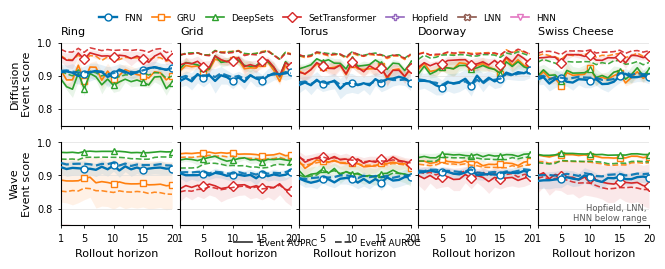

In [84]:
from matplotlib.lines import Line2D

# ============================================================
# Event metrics to plot together on the same y-axis
# ============================================================

EVENT_METRICS = {
    "event_auprc": {
        "label": "Event AUPRC",
        "linestyle": "-",
        "alpha_fill": 0.10,
        "linewidth_scale": 1.00,
    },
    "event_auroc": {
        "label": "Event AUROC",
        "linestyle": "--",
        "alpha_fill": 0.05,
        "linewidth_scale": 0.95,
    },
}

EVENT_METRIC_ORDER = ["event_auprc", "event_auroc"]


# ============================================================
# 2 x 5 figure:
#   rows    = dynamics
#   cols    = topologies
#   y-axis  = event metric (AUPRC / AUROC), shared within row
# ============================================================

fig, axes = plt.subplots(
    len(DYNAMIC_ORDER),
    len(TOPOLOGY_ORDER),
    figsize=(6.5, 2.5),
    sharex=True,
    sharey="row",
)

legend_handles = {}

for row_idx, dynamic in enumerate(DYNAMIC_ORDER):
    for col_idx, topology in enumerate(TOPOLOGY_ORDER):

        ax = axes[row_idx, col_idx]

        panel = horizon_test[
            (horizon_test["dynamic"] == dynamic)
            & (horizon_test["topology"] == topology)
        ]

        draw_order = [run for run in MODEL_ORDER if run != "fnn"] + ["fnn"]

        for run in draw_order:
            model_data = panel[panel["run"] == run]

            if model_data.empty:
                continue

            color = MODEL_COLORS[run]

            for metric in EVENT_METRIC_ORDER:
                metric_cfg = EVENT_METRICS[metric]

                seed_curves = {
                    seed: dict(
                        zip(
                            seed_df["horizon"],
                            seed_df[metric],
                        )
                    )
                    for seed, seed_df in model_data.groupby("seed")
                }

                steps, mean, lower, upper = aggregate_seed_curves(seed_curves)

                marker_indices = [
                    steps.index(step)
                    for step in MARKER_STEPS
                    if step in steps
                ]

                # Keep the filled band only for AUPRC to avoid overplot clutter.
                if metric == "event_auprc":
                    ax.fill_between(
                        steps,
                        lower,
                        upper,
                        color=color,
                        alpha=metric_cfg["alpha_fill"],
                        linewidth=0,
                        zorder=1,
                    )

                line, = ax.plot(
                    steps,
                    mean,
                    color=color,
                    linestyle=metric_cfg["linestyle"],
                    linewidth=MODEL_LINEWIDTHS[run] * metric_cfg["linewidth_scale"],
                    marker=MODEL_MARKERS[run] if metric == "event_auprc" else None,
                    markersize=5.0 if run == "fnn" else 4.6,
                    markerfacecolor="white",
                    markeredgecolor=color,
                    markeredgewidth=1.0,
                    markevery=marker_indices if metric == "event_auprc" else None,
                    zorder=4 if run == "fnn" else 2,
                    alpha=1.0 if metric == "event_auprc" else 0.90,
                    label=MODEL_LABELS[run],
                )

                if metric == "event_auprc":
                    legend_handles.setdefault(run, line)

        # ----------------------------------------------------
        # Panel styling
        # ----------------------------------------------------
        if row_idx == 0:
            ax.set_title(
                TOPOLOGY_LABELS[topology].title(),
                loc="left",
            )

        if col_idx == 0:
            ax.set_ylabel(
                f"{DYNAMIC_LABELS[dynamic]}\nEvent score"
            )

        if row_idx == len(DYNAMIC_ORDER) - 1:
            ax.set_xlabel("Rollout horizon")

        ax.set_xlim(1, 20)
        ax.set_xticks([1, 5, 10, 15, 20])
        ax.set_ylim(0.75, 1.0)

        ax.grid(
            axis="y",
            color="0.88",
            linewidth=0.5,
        )
        ax.grid(axis="x", visible=False)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.tick_params(
            axis="both",
            labelsize=7,
            length=2.5,
            width=0.6,
        )


# ============================================================
# Model legend
# ============================================================

present_runs = [
    run for run in MODEL_ORDER
    if run in legend_handles
]

fig.legend(
    [legend_handles[run] for run in present_runs],
    [MODEL_LABELS[run] for run in present_runs],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=len(present_runs),
    frameon=False,
    columnspacing=1.1,
    handlelength=2.0,
)


# ============================================================
# Metric-style legend
# ============================================================

metric_handles = [
    Line2D(
        [0], [0],
        color="0.25",
        linestyle="-",
        linewidth=1.3,
        label="Event AUPRC",
    ),
    Line2D(
        [0], [0],
        color="0.25",
        linestyle="--",
        linewidth=1.3,
        label="Event AUROC",
    ),
]

fig.legend(
    handles=metric_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=2,
    frameon=False,
)


ax.text(
    0.98,
    0.03,
    "Hopfield, LNN,\nHNN below range",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=6,
    color="0.35",
)

# ============================================================
# Layout: no gaps between columns
# ============================================================

fig.subplots_adjust(
    left=0.09,
    right=0.995,
    bottom=0.13,
    top=0.86,
    wspace=0.07,
    hspace=0.20,
)

plt.show()

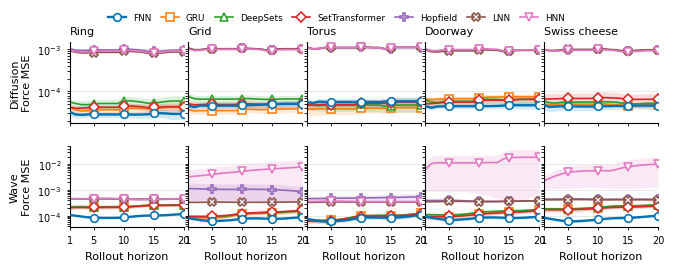

In [93]:
# ============================================================
# 2 x 5 Force NRMSE rollout figure
#   rows    = dynamics
#   cols    = topologies
# ============================================================

fig, axes = plt.subplots(
    len(DYNAMIC_ORDER),
    len(TOPOLOGY_ORDER),
    figsize=(6.5, 2.5),
    sharex=True,
    sharey="row",
)

legend_handles = {}

for row_idx, dynamic in enumerate(DYNAMIC_ORDER):
    for col_idx, topology in enumerate(TOPOLOGY_ORDER):

        ax = axes[row_idx, col_idx]

        panel = horizon_test[
            (horizon_test["dynamic"] == dynamic)
            & (horizon_test["topology"] == topology)
        ]

        draw_order = [
            run for run in MODEL_ORDER
            if run != "fnn"
        ] + ["fnn"]

        for run in draw_order:
            model_data = panel[
                panel["run"] == run
            ]

            if model_data.empty:
                continue

            seed_curves = {
                seed: dict(
                    zip(
                        seed_df["horizon"],
                        seed_df["force_mse"],
                    )
                )
                for seed, seed_df in model_data.groupby("seed")
            }

            steps, mean, lower, upper = aggregate_seed_curves(
                seed_curves
            )

            line = plot_model_curve(
                ax,
                steps,
                mean,
                lower,
                upper,
                run,
            )

            legend_handles.setdefault(run, line)

        # Column titles
        if row_idx == 0:
            ax.set_title(
                TOPOLOGY_LABELS[topology],
                loc="left",
            )

        # Row labels / metric
        if col_idx == 0:
            ax.set_ylabel(
                f"{DYNAMIC_LABELS[dynamic]}\nForce MSE"
            )

        # X labels only on bottom row
        if row_idx == len(DYNAMIC_ORDER) - 1:
            ax.set_xlabel("Rollout horizon")

        ax.set_xlim(1, 20)
        ax.set_xticks([1, 5, 10, 15, 20])

        ax.set_yscale("log")


        ax.grid(
            axis="y",
            color="0.88",
            linewidth=0.5,
        )
        ax.grid(axis="x", visible=False)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.tick_params(
            axis="both",
            length=2.5,
            width=0.6,
        )


# ============================================================
# Shared legend
# ============================================================

present_runs = [
    run for run in MODEL_ORDER
    if run in legend_handles
]

fig.legend(
    [legend_handles[run] for run in present_runs],
    [MODEL_LABELS[run] for run in present_runs],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=len(present_runs),
    frameon=False,
    columnspacing=1.1,
    handlelength=2.0,
)


# ============================================================
# Layout
# ============================================================

fig.subplots_adjust(
    left=0.09,
    right=0.995,
    bottom=0.12,
    top=0.86,
    wspace=0.04,
    hspace=0.28,
)

plt.show()